Cell 1 — Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

PROJECT_ROOT = '/content/drive/MyDrive/PitWall'
DB_PATH      = f'{PROJECT_ROOT}/pitwall.db'
REPORTS_DIR  = f'{PROJECT_ROOT}/reports'
Path(REPORTS_DIR).mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_SEASON  = 2024
print('Setup OK.')

Mounted at /content/drive
Setup OK.


Cell 2 — Load features + train/test split

In [2]:
with sqlite3.connect(DB_PATH) as conn:
    features = pd.read_sql('SELECT * FROM team_season_features', conn)

# finish_rate dropped: zero variance (constant 1.0) → unusable
FEATURE_COLS = [
    'avg_grid',
    'avg_qual_gap_to_pole',
    'pole_count',
    'dnf_rate',
    'avg_qual_to_race_delta',
    'races_entered',
    'season',
]
TARGET = 'total_points'

train = features[features['season'] < TEST_SEASON].reset_index(drop=True)
test  = features[features['season'] == TEST_SEASON].reset_index(drop=True)

X_train, y_train = train[FEATURE_COLS].values, train[TARGET].values
X_test,  y_test  = test[FEATURE_COLS].values,  test[TARGET].values

print(f'Train: {X_train.shape}  ({train["season"].min()}–{train["season"].max()})')
print(f'Test:  {X_test.shape}   (season {TEST_SEASON})')
print(f'Test teams: {test["name"].tolist()}')

Train: (102, 7)  (2014–2023)
Test:  (10, 7)   (season 2024)
Test teams: ['McLaren', 'Ferrari', 'Red Bull', 'Mercedes', 'Aston Martin', 'Alpine F1 Team', 'Haas F1 Team', 'RB F1 Team', 'Williams', 'Sauber']



Cell 3 — 5-fold CV evaluator

In [3]:
def cv_eval(model, X, y, name):
    kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    rmse = -cross_val_score(model, X, y, cv=kf, scoring='neg_root_mean_squared_error')
    r2   =  cross_val_score(model, X, y, cv=kf, scoring='r2')
    mae  = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_absolute_error')
    print(f'{name:20s}  RMSE {rmse.mean():6.1f} ± {rmse.std():.1f}   '
          f'R² {r2.mean():.3f} ± {r2.std():.3f}   '
          f'MAE {mae.mean():6.1f} ± {mae.std():.1f}')
    return {'cv_rmse': rmse.mean(), 'cv_rmse_std': rmse.std(),
            'cv_r2':   r2.mean(),   'cv_r2_std':   r2.std(),
            'cv_mae':  mae.mean(),  'cv_mae_std':  mae.std()}

print('Evaluator ready.')

Evaluator ready.


Cell 4 — Linear Regression baseline

In [4]:
linreg_pipe = Pipeline([
    ('scale', StandardScaler()),
    ('lr',    LinearRegression()),
])

cv_lr = cv_eval(linreg_pipe, X_train, y_train, 'LinearRegression')

linreg_pipe.fit(X_train, y_train)
yhat_lr = linreg_pipe.predict(X_test)
test_lr = {
    'rmse': np.sqrt(mean_squared_error(y_test, yhat_lr)),
    'r2':   r2_score(y_test, yhat_lr),
    'mae':  mean_absolute_error(y_test, yhat_lr),
}
print(f'LR test {TEST_SEASON}:    RMSE {test_lr["rmse"]:.1f}   R² {test_lr["r2"]:.3f}   MAE {test_lr["mae"]:.1f}')

coefs = pd.Series(linreg_pipe.named_steps['lr'].coef_,
                  index=FEATURE_COLS).sort_values(key=abs, ascending=False)
print('\nLR coefficients (standardised):')
print(coefs.round(2))

LinearRegression      RMSE   53.6 ± 4.9   R² 0.933 ± 0.017   MAE   43.3 ± 1.3
LR test 2024:    RMSE 50.7   R² 0.959   MAE 38.4

LR coefficients (standardised):
avg_grid                 -242.04
pole_count                 76.02
avg_qual_to_race_delta    -59.75
avg_qual_gap_to_pole       54.42
dnf_rate                   16.92
races_entered              15.58
season                      3.45
dtype: float64


Cell 5 — Decision Tree baseline

In [5]:
dt = DecisionTreeRegressor(max_depth=5, min_samples_leaf=3, random_state=RANDOM_STATE)
cv_dt = cv_eval(dt, X_train, y_train, 'DecisionTree d=5')

dt.fit(X_train, y_train)
yhat_dt = dt.predict(X_test)
test_dt = {
    'rmse': np.sqrt(mean_squared_error(y_test, yhat_dt)),
    'r2':   r2_score(y_test, yhat_dt),
    'mae':  mean_absolute_error(y_test, yhat_dt),
}
print(f'DT test {TEST_SEASON}:    RMSE {test_dt["rmse"]:.1f}   R² {test_dt["r2"]:.3f}   MAE {test_dt["mae"]:.1f}')

imp = pd.Series(dt.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print('\nDT feature importance:')
print(imp.round(3))

DecisionTree d=5      RMSE   71.6 ± 16.5   R² 0.885 ± 0.029   MAE   45.5 ± 10.2
DT test 2024:    RMSE 96.3   R² 0.851   MAE 64.5

DT feature importance:
avg_grid                  0.879
pole_count                0.092
avg_qual_to_race_delta    0.023
races_entered             0.003
season                    0.002
dnf_rate                  0.002
avg_qual_gap_to_pole      0.000
dtype: float64


Cell 6 — Comparison table

In [6]:
results_df = pd.DataFrame([
    {'model': 'LinearRegression',
     'cv_rmse': cv_lr['cv_rmse'], 'cv_r2': cv_lr['cv_r2'], 'cv_mae': cv_lr['cv_mae'],
     'test_rmse': test_lr['rmse'], 'test_r2': test_lr['r2'], 'test_mae': test_lr['mae']},
    {'model': 'DecisionTree d=5',
     'cv_rmse': cv_dt['cv_rmse'], 'cv_r2': cv_dt['cv_r2'], 'cv_mae': cv_dt['cv_mae'],
     'test_rmse': test_dt['rmse'], 'test_r2': test_dt['r2'], 'test_mae': test_dt['mae']},
])
print('Baseline summary:')
print(results_df.round(3).to_string(index=False))
results_df.to_csv(f'{REPORTS_DIR}/sprint2_baselines_metrics.csv', index=False)
print(f'\nSaved → {REPORTS_DIR}/sprint2_baselines_metrics.csv')

Baseline summary:
           model  cv_rmse  cv_r2  cv_mae  test_rmse  test_r2  test_mae
LinearRegression   53.554  0.933  43.279     50.725    0.959    38.409
DecisionTree d=5   71.606  0.885  45.508     96.312    0.851    64.480

Saved → /content/drive/MyDrive/PitWall/reports/sprint2_baselines_metrics.csv


Cell 7 — Predictions vs actual scatter (test season 2024)

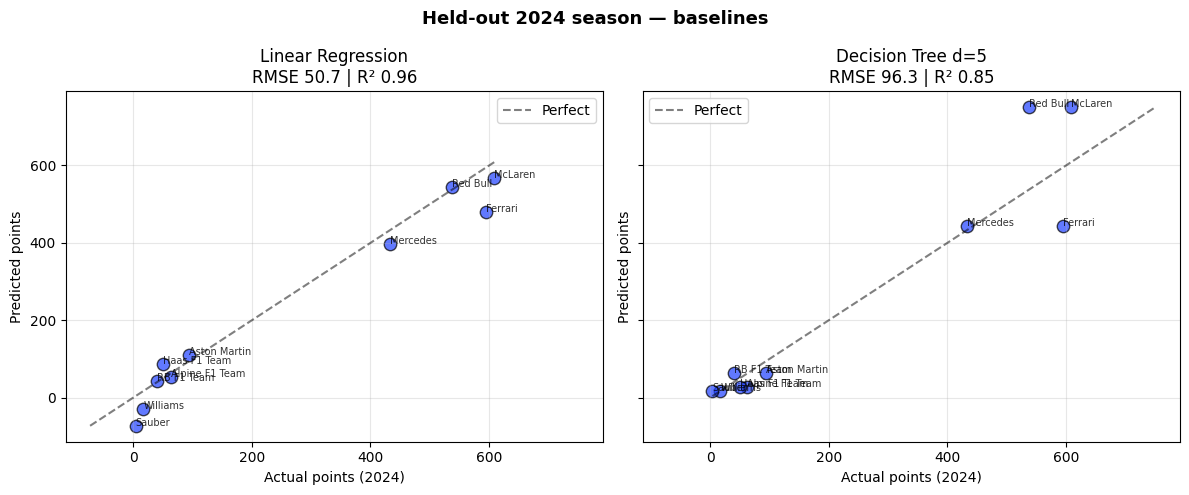

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, yhat, name, m in [
    (axes[0], yhat_lr, 'Linear Regression', test_lr),
    (axes[1], yhat_dt, 'Decision Tree d=5', test_dt),
]:
    ax.scatter(y_test, yhat, s=80, alpha=0.7, color='#1E41FF', edgecolor='k')
    lo, hi = min(y_test.min(), yhat.min()), max(y_test.max(), yhat.max())
    ax.plot([lo, hi], [lo, hi], 'k--', alpha=0.5, label='Perfect')
    for i, name_t in enumerate(test['name']):
        ax.annotate(name_t, (y_test[i], yhat[i]), fontsize=7, alpha=0.8)
    ax.set_xlabel(f'Actual points ({TEST_SEASON})')
    ax.set_ylabel('Predicted points')
    ax.set_title(f'{name}\nRMSE {m["rmse"]:.1f} | R² {m["r2"]:.2f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f'Held-out {TEST_SEASON} season — baselines', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{REPORTS_DIR}/sprint2_02_baselines_test.png', dpi=150, bbox_inches='tight')
plt.show()

Cell 8 — Save predictions

In [8]:
preds = test[['season', 'name', 'constructor_id', TARGET]].copy()
preds['lr_pred']     = yhat_lr.round(1)
preds['dt_pred']     = yhat_dt.round(1)
preds['lr_residual'] = (preds[TARGET] - preds['lr_pred']).round(1)
preds['dt_residual'] = (preds[TARGET] - preds['dt_pred']).round(1)
preds = preds.sort_values(TARGET, ascending=False).reset_index(drop=True)

print(f'Held-out {TEST_SEASON} predictions:')
print(preds.to_string(index=False))

preds.to_csv(f'{REPORTS_DIR}/sprint2_baselines_test_preds.csv', index=False)
print(f'\nSaved → {REPORTS_DIR}/sprint2_baselines_test_preds.csv')

Held-out 2024 predictions:
 season           name constructor_id  total_points  lr_pred  dt_pred  lr_residual  dt_residual
   2024        McLaren        mclaren         609.0    568.1    751.0         40.9       -142.0
   2024        Ferrari        ferrari         595.0    480.4    442.7        114.6        152.3
   2024       Red Bull       red_bull         537.0    544.0    751.0         -7.0       -214.0
   2024       Mercedes       mercedes         433.0    396.3    442.7         36.7         -9.7
   2024   Aston Martin   aston_martin          94.0    109.2     64.4        -15.2         29.6
   2024 Alpine F1 Team         alpine          63.0     54.4     27.1          8.6         35.9
   2024   Haas F1 Team           haas          51.0     85.9     27.1        -34.9         23.9
   2024     RB F1 Team             rb          40.0     43.6     64.4         -3.6        -24.4
   2024       Williams       williams          17.0    -28.9     17.0         45.9          0.0
   2024      